In [1]:
import math
from functools import partial
from typing import Any, Callable, List, Optional, Sequence

import torch
from torch import nn, Tensor

from torchvision.models.mobilenetv3 import (
    MobileNetV3,
    InvertedResidualConfig,
    _mobilenet_v3_conf,
    _mobilenet_v3,
)

In [2]:
# ----------------------------
# 1. Define the CoordAtt Module
# ----------------------------
class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        """
        CoordAtt module that embeds positional information into channel attention.
        Here we assume inp==oup.
        """
        super().__init__()
        # Pool along each spatial dimension separately
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        # Use a simple intermediate channel reduction
        mip = max(8, inp // groups)

        # Shared 1x1 convolution to mix the two pooled features
        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        # Two separate convs to produce attention for height and width
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()

    def forward(self, x):
        identity = x
        n, c, h, w = x.size()
        # Pool along height and width
        x_h = self.pool_h(x)  # shape: (n, c, h, 1)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)  # shape: (n, c, w, 1)

        # Concatenate along the spatial dimension
        y = torch.cat([x_h, x_w], dim=2)  # shape: (n, c, h+w, 1)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y)
        # Split back to height and width attention maps
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        # Generate attention maps and apply sigmoid activation
        a_h = self.conv2(x_h).sigmoid()
        a_w = self.conv3(x_w).sigmoid()

        # Expand and multiply with the input feature
        a_h = a_h.expand(-1, -1, h, w)
        a_w = a_w.expand(-1, -1, h, w)
        out = identity * a_h * a_w
        return out

In [3]:
# ----------------------------
# 2. Create CA-enabled Inverted Residual Block for MobileNetV3
# ----------------------------
class InvertedResidualCA(nn.Module):
    """
    This is a variant of MobileNetV3's InvertedResidual block that uses
    the CoordAtt module instead of SqueezeExcitation when use_se is True.
    """
    def __init__(
        self,
        cnf: InvertedResidualConfig,
        norm_layer: Callable[..., nn.Module],
        # we use 'attn_layer' to inject the CoordAtt module.
        # If attn_layer is None, then we use the default SElayer (as in the original code)
        attn_layer: Optional[Callable[..., nn.Module]] = None,
    ):
        super().__init__()
        if not (1 <= cnf.stride <= 2):
            raise ValueError("illegal stride value")
        self.use_res_connect = cnf.stride == 1 and cnf.input_channels == cnf.out_channels

        layers: List[nn.Module] = []
        activation_layer = nn.Hardswish if cnf.use_hs else nn.ReLU

        # Expand phase: 1x1 conv (if needed)
        if cnf.expanded_channels != cnf.input_channels:
            layers.append(
                nn.Sequential(
                    nn.Conv2d(cnf.input_channels, cnf.expanded_channels, kernel_size=1, bias=False),
                    norm_layer(cnf.expanded_channels),
                    activation_layer(inplace=True),
                )
            )

        # Depthwise convolution
        stride = 1 if cnf.dilation > 1 else cnf.stride
        layers.append(
            nn.Sequential(
                nn.Conv2d(
                    cnf.expanded_channels,
                    cnf.expanded_channels,
                    kernel_size=cnf.kernel,
                    stride=stride,
                    padding=cnf.kernel // 2,
                    dilation=cnf.dilation,
                    groups=cnf.expanded_channels,
                    bias=False,
                ),
                norm_layer(cnf.expanded_channels),
                activation_layer(inplace=True),
            )
        )

        # Attention module: if use_se is True, use CoordAtt if provided;
        # otherwise (if attn_layer is None) use the original SElayer.
        if cnf.use_se:
            if attn_layer is not None:
                # For CoordAtt we pass (in_channels, in_channels)
                layers.append(attn_layer(cnf.expanded_channels, cnf.expanded_channels))
            else:
                # Fallback: use the original squeeze excitation.
                from torchvision.models.mobilenetv3 import SqueezeExcitation as SElayer
                squeeze_channels = (cnf.expanded_channels // 4)
                # Ensure the channel count is divisible by 8 (as done in original code)
                from torchvision.models.mobilenetv3 import _make_divisible
                squeeze_channels = _make_divisible(squeeze_channels, 8)
                layers.append(SElayer(cnf.expanded_channels, squeeze_channels))

        # Project phase: 1x1 conv (no activation)
        layers.append(
            nn.Sequential(
                nn.Conv2d(cnf.expanded_channels, cnf.out_channels, kernel_size=1, bias=False),
                norm_layer(cnf.out_channels),
            )
        )
        self.block = nn.Sequential(*layers)
        self.out_channels = cnf.out_channels
        self._is_cn = cnf.stride > 1

    def forward(self, input: Tensor) -> Tensor:
        result = self.block(input)
        if self.use_res_connect:
            result += input
        return result

In [4]:
# ----------------------------
# 3. Build MobileNetV3 Large with CA Module
# ----------------------------
def mobilenet_v3_ca_large(*, weights: Optional[Any] = None, progress: bool = True, **kwargs: Any) -> MobileNetV3:
    """
    Constructs a MobileNetV3 large network that integrates the CoordAtt module
    (CA) in place of the original squeeze-excitation blocks.

    Args:
        weights: Optional pretrained weights.
        progress: If True, display a progress bar.
        **kwargs: Additional arguments passed to the MobileNetV3 constructor.
    """
    # Get configuration for MobileNetV3 large.
    inverted_residual_setting, last_channel = _mobilenet_v3_conf("mobilenet_v3_large", **kwargs)

    # Here we use our CA-enabled block instead of the original InvertedResidual.
    # We pass our CoordAtt module via the 'attn_layer' parameter.
    block = lambda cnf, norm_layer: InvertedResidualCA(cnf, norm_layer, attn_layer=CoordAtt)

    # Build the model with the modified block.
    model = MobileNetV3(inverted_residual_setting, last_channel, block=block, **kwargs)

    # (Optional) If weights are provided, load the pretrained state dict.
    if weights is not None:
        state_dict = weights.get_state_dict(progress=progress, check_hash=True)
        model.load_state_dict(state_dict)

    return model

In [5]:
import os
import zipfile
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [6]:
!pip install grad-cam

In [7]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [8]:
# ----------------------------
# Here we alias our function for easier usage.
MobileNetV3LargeCA = mobilenet_v3_ca_large

In [9]:
class GradCAMWrapper:
    def __init__(self, model):
        self.model = model
        # Here, we point to the last feature layer from model.features rather than model.model.features
        self.target_layers = [self.model.features[-1]]
        self.cam = GradCAM(model=self.model,
                           target_layers=self.target_layers,
                           #use_cuda=torch.cuda.is_available()
                           )

    def visualize(self, input_tensor, rgb_img=None):
        grayscale_cam = self.cam(input_tensor=input_tensor)
        grayscale_cam = grayscale_cam[0, :]
        if rgb_img is None:
            rgb_img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
            rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        return visualization

In [10]:
# ----------------------------
# Data loader, training, and evaluation functions
def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    train_transforms = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_test_transforms = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), val_test_transforms)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, val_loader, test_loader

In [11]:
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [12]:
def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=16, model_path='best_model.pth'):
    model.load_state_dict(torch.load(model_path))
    model.to(device).eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    plt.figure(figsize=(12, 12))
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        plt.subplot(4, 4, idx + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
def show_gradcam_examples(model, test_loader, device, class_names, num_examples=16):
    cam_wrapper = GradCAMWrapper(model)
    model.eval()

    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    plt.figure(figsize=(12, 12))
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        visualization = cam_wrapper.visualize(inputs[idx].unsqueeze(0), img)

        plt.subplot(4, 4, idx + 1)
        plt.imshow(visualization)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [14]:
def evaluate_model(model, test_loader, device, class_names, model_path='best_model.pth'):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: DataLoader for the test dataset.
        device: The device to use for computation (e.g., 'cuda' or 'cpu').
        class_names: A list of class names.
        model_path: Path to the model file to load. Defaults to 'best_model.pth'.
    """
    model.load_state_dict(torch.load(model_path))  # Load from the specified path
    model.to(device)
    model.eval()

    y_true, y_pred = [], []
    total, correct = 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [15]:
# ----------------------------
# Mount Google Drive and prepare dataset paths
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
num_epochs_initial = 40
learning_rate_initial = 3e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Extract dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [17]:
data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [18]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

In [19]:
# 1. Load the pretrained MobileNetV3 large model and get its state dict.
pretrained_model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
pretrained_state_dict = pretrained_model.state_dict()

# 2. Instantiate your CA-enabled model.
model = MobileNetV3LargeCA(num_classes=num_classes)

# 3. Get the state dict of your CA-enabled model.
model_state_dict = model.state_dict()

# 4. Update matching layers from the pretrained state dict.
for name, param in pretrained_state_dict.items():
    if name in model_state_dict and model_state_dict[name].shape == param.shape:
        model_state_dict[name] = param

# 5. Load the updated state dict into your model.
model.load_state_dict(model_state_dict)
print("Loaded pretrained weights for matching layers.")

Loaded pretrained weights for matching layers.


In [20]:
!pip install torchinfo

In [21]:
from torchinfo import summary

In [22]:
# Print updated model architecture and summary after modifying the classifier
print("\nDetailed Model Architecture (After modifying classifier):")
print(model)
print("\nUpdated Model Summary (After modifying classifier):")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Detailed Model Architecture (After modifying classifier):
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidualCA(
      (block): Sequential(
        (0): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Sequential(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidualCA(
      (block): Sequential(
        (0): Sequential(
          (0): Conv2d(16, 64, kern

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualCA: 2-2                     [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         464
│    └─InvertedResidualCA: 2-3                     [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           3,440
│    └─InvertedResidualCA: 2-4                     [1, 24, 64, 64]           --
│    │    └─Sequential: 3-6   

In [23]:
# ====== Helper Functions for Freezing / Unfreezing ======
def freeze_all_except_classifier_and_attention(model):
    """
    Freeze all parameters in the model except for:
      - Those in the classifier.
      - Those in any attention module (i.e. instances of CoordAtt).
    """
    # Freeze everything first.
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze classifier parameters.
    for name, param in model.named_parameters():
        if "classifier" in name:
            param.requires_grad = True

    # Recursively unfreeze attention modules.
    def unfreeze_attention(module):
        for child in module.children():
            # Change this if your attention module has a different class name.
            if isinstance(child, CoordAtt):
                for p in child.parameters():
                    p.requires_grad = True
            else:
                unfreeze_attention(child)
    unfreeze_attention(model)


def unfreeze_last_n_layers_and_attention(model, n):
    """
    Unfreeze the last 'n' parameters (in the order returned by model.named_parameters())
    and ensure that attention (CoordAtt) modules remain trainable.
    """
    # Unfreeze the last n parameters.
    params = list(model.named_parameters())
    for name, param in params[-n:]:
        param.requires_grad = True

    # Also ensure that any parameter from a CoordAtt module is trainable.
    def unfreeze_attention(module):
        for child in module.children():
            if isinstance(child, CoordAtt):
                for p in child.parameters():
                    p.requires_grad = True
            else:
                unfreeze_attention(child)
    unfreeze_attention(model)

def unfreeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = True

In [24]:
# ====== Function to Print Model Summary ======
def print_model_summary(model, input_size=(1, 3, 256, 256)):
    print("\n==== Model Summary ====")
    print(summary(model, input_size=input_size))
    print("=======================\n")

In [25]:
# ====== Function to Show True vs Predicted Images and GradCAM Visualizations ======
def show_visualizations(model, test_loader, device, class_names):
    print("\nTrue vs Predicted Images:")
    plot_true_vs_predicted(model, test_loader, device, class_names)
    print("\nGrad-CAM Visualizations:")
    show_gradcam_examples(model, test_loader, device, class_names)

In [26]:
# ====== Stage 1: Train Only the Classifier ======
print("Stage 1: Training only the classifier layer.")

# Freeze everything except the classifier
freeze_all_except_classifier_and_attention(model)
print_model_summary(model)

Stage 1: Training only the classifier layer.

==== Model Summary ====
Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualCA: 2-2                     [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         (464)
│    └─InvertedResidualCA: 2-3                     [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           (3,440)
│    └─InvertedResidualCA: 2-4  

Epoch 1/40 | Train Loss: 0.6764 Acc: 76.95% | Val Loss: 0.3443 Acc: 89.32% | Time: 45.15s | 152.94 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.3065 Acc: 88.88% | Val Loss: 0.2169 Acc: 93.35% | Time: 30.72s | 224.82 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 0.1941 Acc: 92.95% | Val Loss: 0.1914 Acc: 94.02% | Time: 32.24s | 214.23 samples/s
Best model saved to best_model.pth
Epoch 4/40 | Train Loss: 0.1574 Acc: 94.18% | Val Loss: 0.1528 Acc: 95.30% | Time: 31.65s | 218.19 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 0.1165 Acc: 95.87% | Val Loss: 0.1494 Acc: 94.76% | Time: 31.94s | 216.19 samples/s
Epoch 6/40 | Train Loss: 0.0901 Acc: 96.71% | Val Loss: 0.1583 Acc: 95.10% | Time: 32.18s | 214.62 samples/s
Epoch 7/40 | Train Loss: 0.0780 Acc: 97.55% | Val Loss: 0.1383 Acc: 95.70% | Time: 31.28s | 220.78 samples/s
Best model saved to best_model.pth
Epoch 8/40 | Train Loss: 0.0584 Acc: 97.80% | Val Loss: 0.1531 Acc: 95.77% | Time: 31.09s | 222.13 samples/s
Best model saved to best_model.pth
Epoch 9/40 | Train Loss: 0.0556 Acc: 98.05% | Val Loss: 0.1290

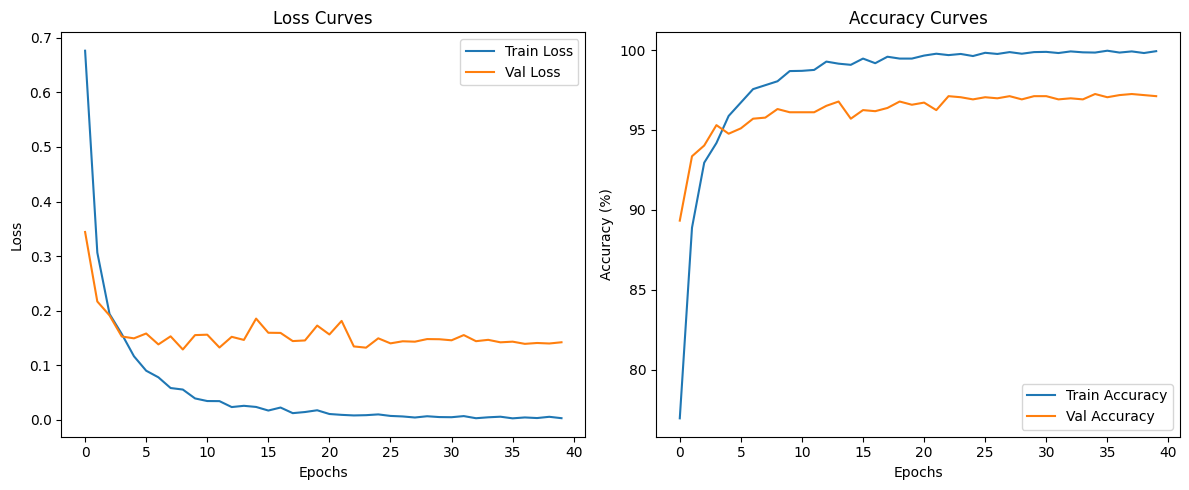

In [27]:
# Create an optimizer for only trainable parameters
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate_initial)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)

# Train the model (use your train_model function)
train_model(model, train_loader, val_loader, num_epochs=num_epochs_initial,
            optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 96.60%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.92      0.91      0.92       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.99      0.99      0.99       148
             betel_Healthy Leaf       0.91      0.92      0.92       148
                 tea_algal_spot       0.99      0.99      0.99       150
               tea_brown_blight       0.94      0.97      0.95       130
                tea_gray_blight       0.97      0.95      0.96       150
                    tea_healthy       0.95      0.99      0.97       150
                 tea_helopeltis       1.00      0.95      0.98       150
                   tea_red_spot       0.99      0.99      0.99       150

                       accuracy                           0.97      1472
                      macro avg       0.97      0.97      0.97      1472
  

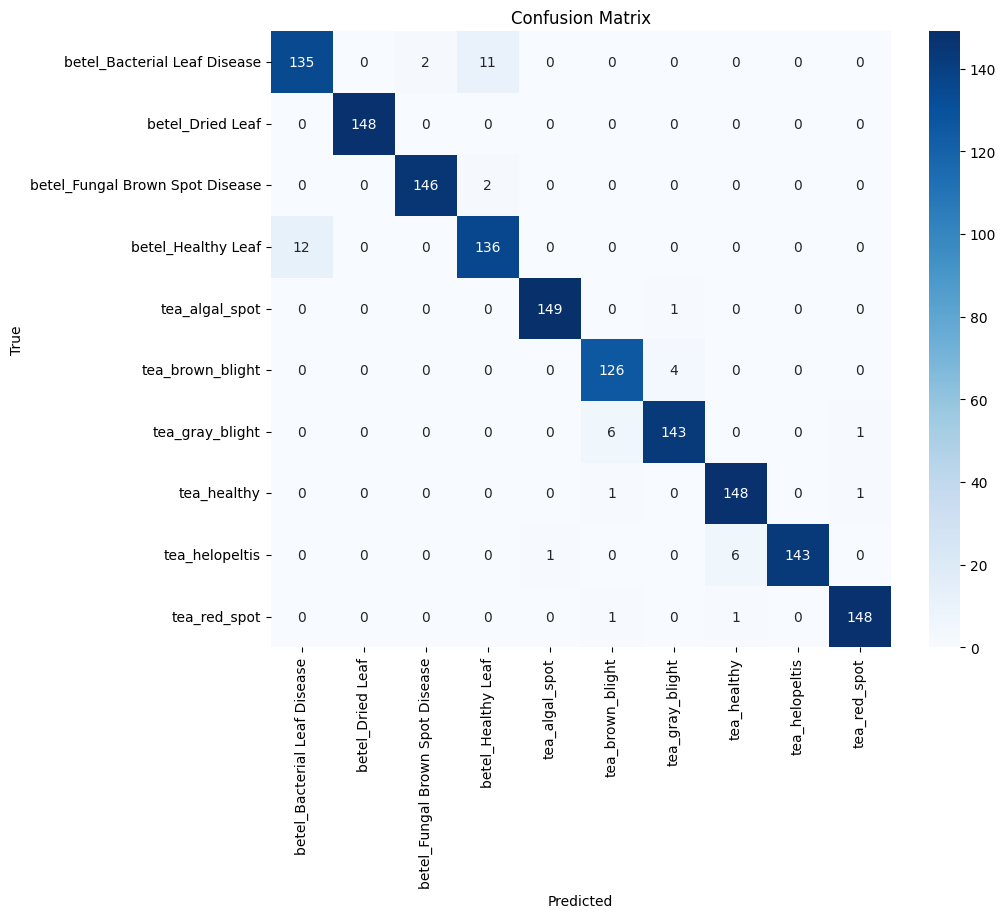

In [28]:
# Evaluate after Stage 1
evaluate_model(model, test_loader, device, class_names)
#show_visualizations(model, test_loader, device, class_names)

In [29]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [30]:
torch.cuda.empty_cache()

In [31]:
# ====== Stage 2: Fine-Tune the Last N Layers ======
n_layers_to_unfreeze = 20  # Adjust as needed
print(f"\nStage 2: Fine-tuning the last {n_layers_to_unfreeze} layers.")

unfreeze_last_n_layers_and_attention(model, n_layers_to_unfreeze)
print_model_summary(model)


Stage 2: Fine-tuning the last 20 layers.

==== Model Summary ====
Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualCA: 2-2                     [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         (464)
│    └─InvertedResidualCA: 2-3                     [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           (3,440)
│    └─InvertedResidualCA: 2-4     

Epoch 1/40 | Train Loss: 0.0315 Acc: 98.96% | Val Loss: 0.1418 Acc: 96.44% | Time: 31.41s | 219.90 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.0243 Acc: 99.26% | Val Loss: 0.1370 Acc: 96.17% | Time: 32.91s | 209.86 samples/s
Epoch 3/40 | Train Loss: 0.0212 Acc: 99.25% | Val Loss: 0.1377 Acc: 96.37% | Time: 31.23s | 221.14 samples/s
Epoch 4/40 | Train Loss: 0.0228 Acc: 99.32% | Val Loss: 0.1369 Acc: 96.91% | Time: 31.00s | 222.79 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 0.0149 Acc: 99.49% | Val Loss: 0.1718 Acc: 96.71% | Time: 32.53s | 212.28 samples/s
Epoch 6/40 | Train Loss: 0.0131 Acc: 99.55% | Val Loss: 0.1376 Acc: 96.78% | Time: 31.11s | 221.95 samples/s
Epoch 7/40 | Train Loss: 0.0178 Acc: 99.41% | Val Loss: 0.1988 Acc: 95.97% | Time: 30.78s | 224.34 samples/s
Epoch 8/40 | Train Loss: 0.0261 Acc: 99.29% | Val Loss: 0.1401 Acc: 96.71% | Time: 31.25s | 221.03 samples/s
Epoch 9/40 | Train Loss: 0.0109 Acc: 99.61% | Val Loss: 0.1479 Acc: 97.25% | Time: 31.66s | 218.16 samples/s
Best model saved to best_model.pth
Epoch 10/40 | Train Loss: 0.0096 Acc: 99.68% | Val Loss: 0

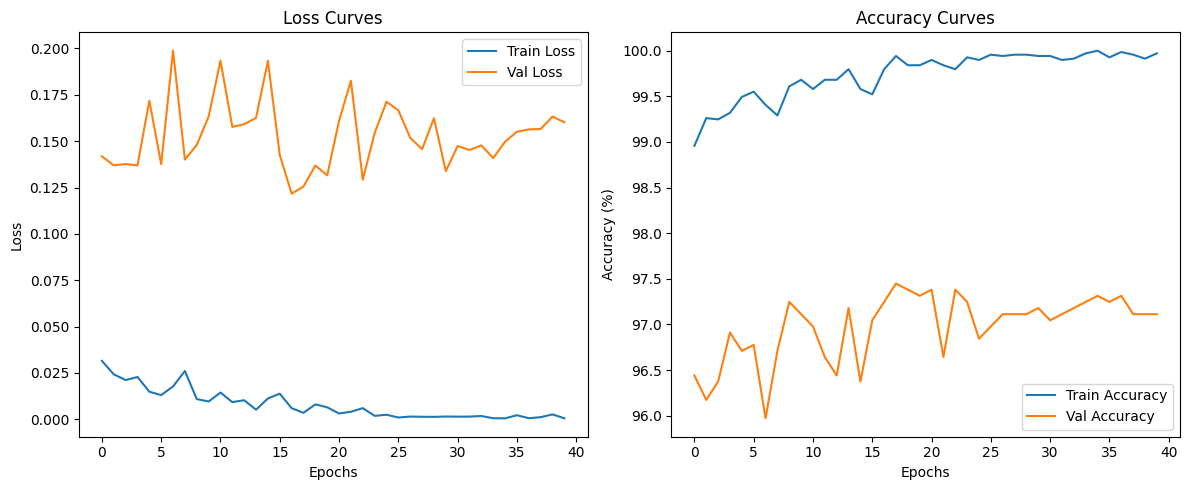

In [32]:
# Re-create the optimizer with the updated trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate_initial)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)

# Train again
train_model(model, train_loader, val_loader, num_epochs=num_epochs_initial,
            optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 97.62%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.94      0.95      0.94       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       1.00      1.00      1.00       148
             betel_Healthy Leaf       0.95      0.94      0.94       148
                 tea_algal_spot       0.98      0.99      0.99       150
               tea_brown_blight       0.96      0.99      0.98       130
                tea_gray_blight       0.99      0.97      0.98       150
                    tea_healthy       0.97      0.98      0.97       150
                 tea_helopeltis       0.99      0.95      0.97       150
                   tea_red_spot       0.99      0.99      0.99       150

                       accuracy                           0.98      1472
                      macro avg       0.98      0.98      0.98      1472
  

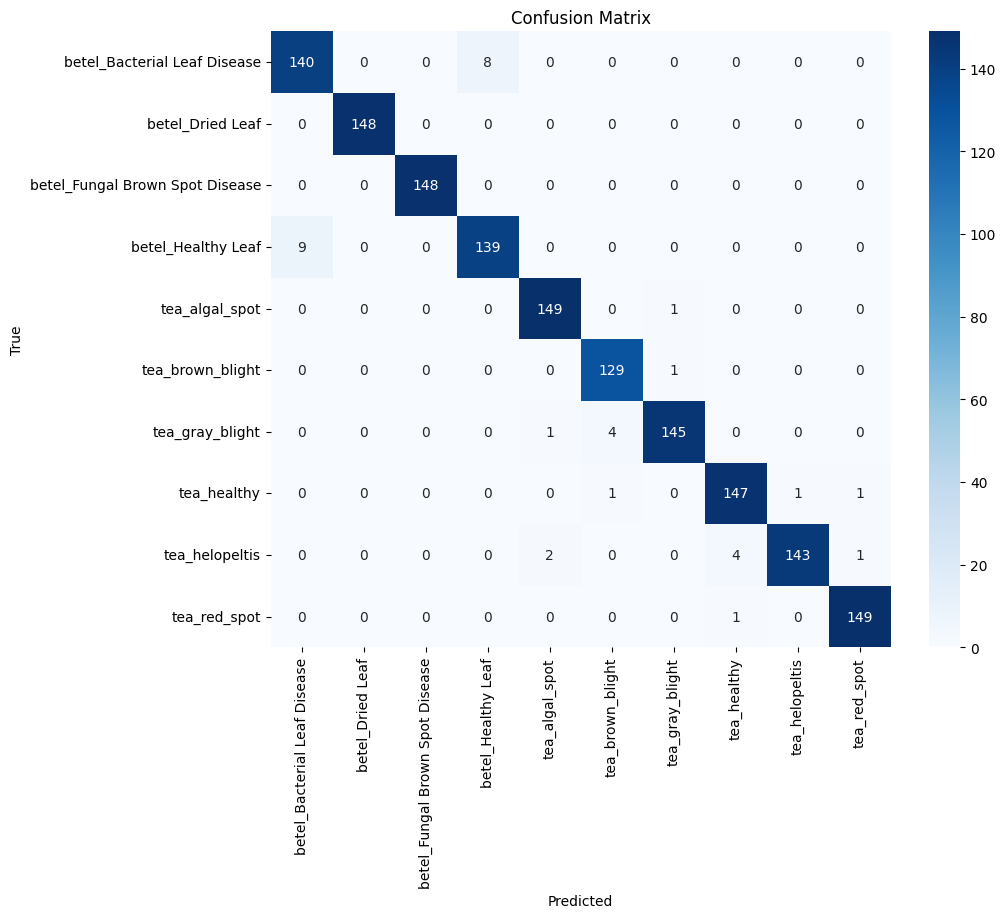

In [33]:
# Evaluate after Stage 2
evaluate_model(model, test_loader, device, class_names)

In [34]:
show_visualizations(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [35]:
torch.cuda.empty_cache()

In [39]:
import os

# Define the path to your model in the Colab notebook
model_path_colab = 'best_model.pth'

# Define the path where you want to save the model in your Google Drive
model_path_drive = '/content/drive/My Drive/MyModels/mobnetV3_large_ca_best_model.pth'  # Create the "MyModels" folder if it doesn't exist

# Save the model to Google Drive
try:
    os.makedirs(os.path.dirname(model_path_drive), exist_ok=True)  # Create the directory if it doesn't exist
    !cp "{model_path_colab}" "{model_path_drive}"
    print(f"Model saved to: {model_path_drive}")
except Exception as e:
    print(f"Error saving model: {e}")

Model saved to: /content/drive/My Drive/MyModels/mobnetV3_large_ca_best_model.pth


In [40]:
_, _, test_loader2 = get_data_loaders(data_dir, batch_size, img_size)


Test Accuracy: 97.62%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.94      0.95      0.94       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       1.00      1.00      1.00       148
             betel_Healthy Leaf       0.95      0.94      0.94       148
                 tea_algal_spot       0.98      0.99      0.99       150
               tea_brown_blight       0.96      0.99      0.98       130
                tea_gray_blight       0.99      0.97      0.98       150
                    tea_healthy       0.97      0.98      0.97       150
                 tea_helopeltis       0.99      0.95      0.97       150
                   tea_red_spot       0.99      0.99      0.99       150

                       accuracy                           0.98      1472
                      macro avg       0.98      0.98      0.98      1472
  

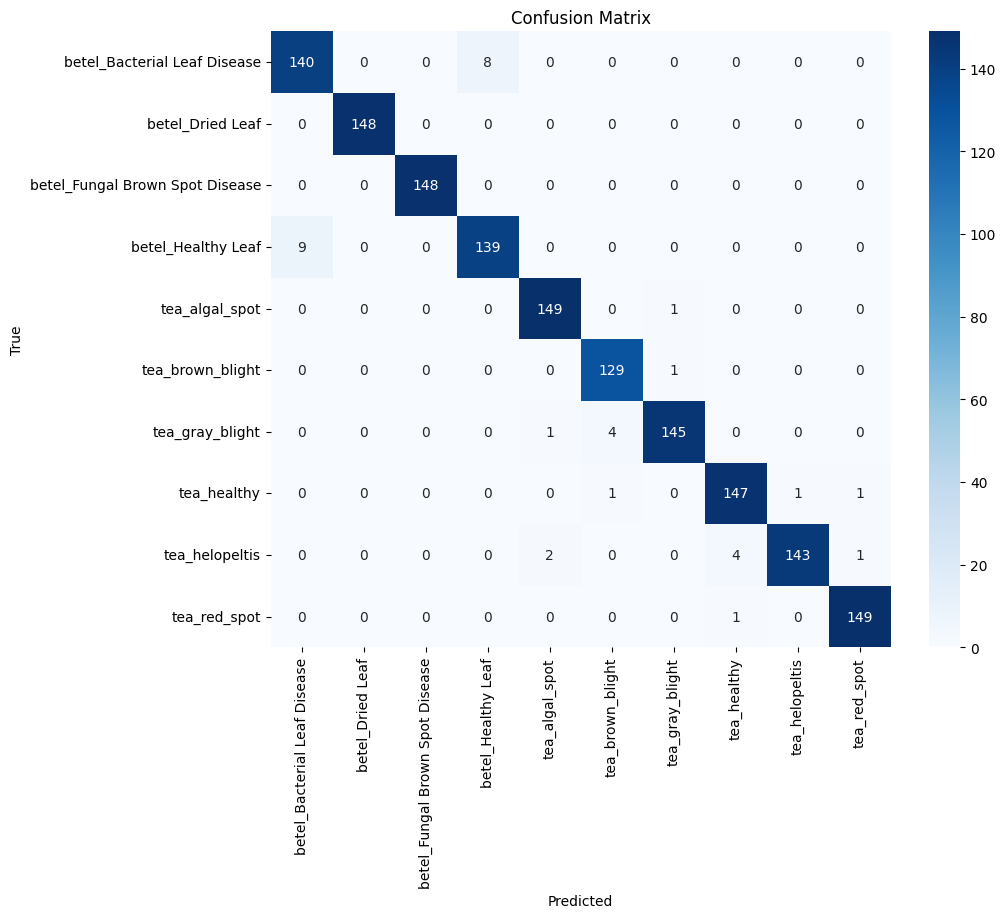

In [41]:
# Load the saved model from Google Drive
model_path_drive = '/content/drive/My Drive/MyModels/mobnetV3_large_ca_best_model.pth'
model.load_state_dict(torch.load(model_path_drive))

# Move the model to the appropriate device
model.to(device)

# Evaluate the model
evaluate_model(model, test_loader2, device, class_names, model_path=model_path_drive)

In [36]:
# # ====== Stage 3: Fine-Tune the Entire Model ======
# print("\nStage 3: Fine-tuning the entire model.")
# unfreeze_all_layers(model)
# print_model_summary(model)

In [37]:
# # Re-create the optimizer to update all parameters
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00001)
# scheduler = CosineAnnealingLR(optimizer, T_max=10)

# # Final training stage
# train_model(model, train_loader, val_loader, num_epochs=10,
#             optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)

In [38]:
# # Final evaluation
# evaluate_model(model, test_loader, device, class_names)
# #show_visualizations(model, test_loader, device, class_names)